# comprension_eda.ipynb — Análisis Exploratorio de Datos (EDA)
## Riesgo Crediticio — Predicción de `Pago_atiempo`
**Autor:** Científico/a de Datos Junior Advanced — Equipo de Datos y Analítica

Este notebook cubre: caracterización de variables, calidad de datos, detección de outliers, reglas de validación, y análisis univariable/bivariable/multivariable, con interpretación de negocio en cada sección.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../Base_de_datos_tipada.csv', parse_dates=['fecha_prestamo'])
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 10763, Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración inicial de datos
### 1.1 Caracterización de variables

| Variable | Tipo | Notas |
|---|---|---|
| capital_prestado, cuota_pactada, salario_cliente, total_otros_prestamos, puntaje, puntaje_datacredito, saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor, promedio_ingresos_datacredito | Numérica continua | Con outliers, ver 1.4 |
| plazo_meses, edad_cliente, cant_creditosvigentes, huella_consulta, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal | Numérica discreta | Conteos |
| tipo_credito, tipo_laboral | Categórica nominal | Sin orden natural |
| tendencia_ingresos | Categórica ordinal (corrupta) | Ver 1.3 |
| fecha_prestamo | Fecha | Útil para drift temporal, no como feature directa (evitar leakage) |
| Pago_atiempo | Dicotómica — **variable objetivo** | 1 = pagó a tiempo, 0 = no pagó a tiempo |

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
tipo_credito,10763.0,6.0,4.0,7747.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52,NaN
capital_prestado,10763.0,NaN,NaN,NaN,2434315.001319,360000.0,1224831.0,1921920.0,3084840.0,41444152.8,1909642.758997
plazo_meses,10763.0,NaN,NaN,NaN,10.575583,2.0,6.0,10.0,12.0,90.0,6.632082
edad_cliente,10763.0,NaN,NaN,NaN,43.94862,19.0,33.0,42.0,53.0,123.0,15.060877
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salario_cliente,10763.0,NaN,NaN,NaN,17216431.459909,0.0,2000000.0,3000000.0,4875808.0,22000000000.0,355476717.603482
total_otros_prestamos,10763.0,NaN,NaN,NaN,6238869.648518,0.0,500000.0,1000000.0,2000000.0,6787675263.0,118418316.941069
cuota_pactada,10763.0,NaN,NaN,NaN,243617.406671,23944.0,121041.5,182863.0,287833.5,3816752.0,210493.694608
puntaje,10763.0,NaN,NaN,NaN,91.170036,-38.00999,95.227787,95.227787,95.227787,95.227787,16.465441


**Interpretación:** al ver `min`/`max` de `describe()` ya saltan valores imposibles: `salario_cliente` llega a 22,000 millones, `puntaje` baja a -38 (debería ser 0-100), `puntaje_datacredito` llega a -7 (debería ser positivo), `edad_cliente` llega a 123 años, y `total_otros_prestamos` llega a 6,787 millones. Esto confirma que el dataset tiene **errores de captura**, no solo nulos. Se cuantifican en la sección 1.4.

### 1.2 Revisión de nulos (unificados)

In [3]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
nulos[nulos > 0].round(2).to_frame('% nulos')

,% nulos
tendencia_ingresos,27.24
promedio_ingresos_datacredito,27.22
saldo_mora_codeudor,5.48
saldo_principal,3.76
saldo_mora,1.45
saldo_total,1.45
puntaje_datacredito,0.06


**Interpretación:** dos columnas concentran la mayoría del problema de nulos — `tendencia_ingresos` (27.24%) y `promedio_ingresos_datacredito` (27.22%), casi las mismas filas probablemente (mismo origen de datos faltante). El resto (saldos y puntaje_datacredito) tiene nulos menores al 6%, manejables con imputación simple.

### 1.3 Hallazgo de calidad de datos: `tendencia_ingresos`
Debería ser categórica ordinal (Estable / Creciente / Decreciente), pero trae valores numéricos sueltos mezclados (error de origen/mapeo, probablemente una columna que se corrió o un join mal hecho).

In [4]:
df['tendencia_ingresos'].value_counts(dropna=False).head(10)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
Name: count, dtype: int64

In [5]:
categorias_validas = ['Estable', 'Creciente', 'Decreciente']
es_valida = df['tendencia_ingresos'].isin(categorias_validas)
print(f'Válidos: {es_valida.sum()} ({es_valida.mean()*100:.1f}%)')
print(f'Corruptos (numéricos u otros): {(~es_valida & df["tendencia_ingresos"].notna()).sum()}')
print(f'Nulos: {df["tendencia_ingresos"].isna().sum()}')

df['tendencia_ingresos_limpia'] = df['tendencia_ingresos'].where(es_valida, other='Desconocido')
df['tendencia_ingresos_limpia'].value_counts()

Válidos: 7773 (72.2%)
Corruptos (numéricos u otros): 58
Nulos: 2932


tendencia_ingresos_limpia
Creciente      5294
Desconocido    2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64

**Decisión y justificación:** se recodifica todo lo que no sea una de las 3 categorías válidas como `'Desconocido'`, en vez de imputar con la moda o eliminar filas. Justificación: el problema afecta a ~27% de las filas — imputar con la moda inventaría una tendencia de ingresos para más de una cuarta parte de los clientes, y eliminar esas filas sesgaría fuertemente la muestra. `'Desconocido'` es honesto: le dice al modelo 'no tenemos este dato confiable', sin fingir que sí lo sabemos.

### 1.4 Outliers y reglas de validación de negocio
Se combinan **rangos de negocio razonables** (lo que es físicamente/legalmente posible) con el método estadístico **IQR** para detectar valores atípicos.

In [6]:
reglas_negocio = {
    'edad_cliente': (18, 75),
    'puntaje': (0, 100),
    'puntaje_datacredito': (150, 999),
}
for col, (lo, hi) in reglas_negocio.items():
    invalidos = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: {invalidos} filas fuera del rango válido [{lo}, {hi}] ({invalidos/len(df)*100:.2f}%)')

edad_cliente: 150 filas fuera del rango válido [18, 75] (1.39%)
puntaje: 135 filas fuera del rango válido [0, 100] (1.25%)
puntaje_datacredito: 147 filas fuera del rango válido [150, 999] (1.37%)


In [7]:
def resumen_iqr(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    return outliers, outliers/len(df)*100, lim_sup

for col in ['salario_cliente', 'total_otros_prestamos', 'capital_prestado']:
    n, pct, lim_sup = resumen_iqr(col)
    print(f'{col}: {n} outliers por IQR ({pct:.2f}%), límite superior IQR = {lim_sup:,.0f}')

salario_cliente: 718 outliers por IQR (6.67%), límite superior IQR = 9,189,520
total_otros_prestamos: 589 outliers por IQR (5.47%), límite superior IQR = 4,250,000
capital_prestado: 550 outliers por IQR (5.11%), límite superior IQR = 5,874,854


**Interpretación y regla de validación propuesta:**
- `edad_cliente`, `puntaje`, `puntaje_datacredito` tienen valores **imposibles** (fuera de su rango físico de negocio) en una proporción pequeña → se recomienda **filtrarlos/marcarlos como inválidos** antes del modelado (Avance #2), no imputarlos, porque son errores de captura, no ausencias.
- `salario_cliente` y `total_otros_prestamos` tienen una **cola extrema** de valores absurdamente altos (miles de millones) detectados por IQR → se recomienda aplicar un **cap (winsorización)** al percentil 99, en vez de eliminar esas filas, para no perder clientes que sí pueden tener ingresos altos legítimos mezclados con los errores.
- Estas reglas (rango físico + IQR) son las que se documentarán como **reglas de validación de datos** para producción, tal como pide la consigna.

## 2. Exploración de datos y descripción (EDA)
### 2.1 Análisis univariable — variable objetivo

Pago_atiempo
1    95.25
0     4.75
Name: proportion, dtype: float64


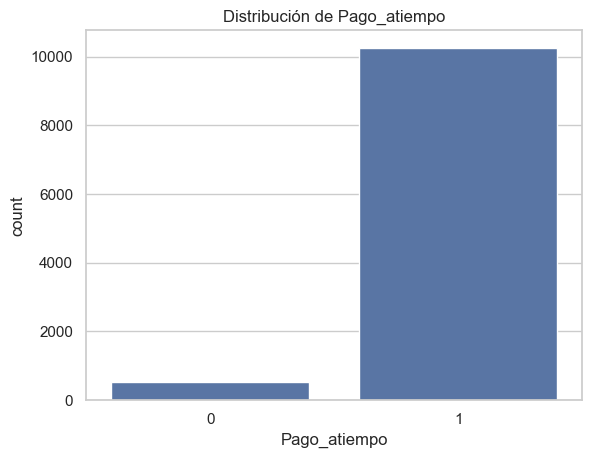

In [8]:
tasa = df['Pago_atiempo'].value_counts(normalize=True) * 100
print(tasa.round(2))
sns.countplot(data=df, x='Pago_atiempo')
plt.title('Distribución de Pago_atiempo')
plt.show()

**Interpretación clave:** el dataset está **fuertemente desbalanceado** — 95.25% paga a tiempo, solo 4.75% no paga. Esto tiene 2 implicaciones directas para el Avance #2: (1) no usar *accuracy* como métrica principal, priorizar ROC-AUC, PR-AUC, recall y F1 de la clase 0; (2) considerar `class_weight='balanced'` o técnicas de sobremuestreo (SMOTE) al entrenar, porque un modelo ingenuo que siempre prediga '1' ya acertaría 95% de las veces sin ser útil para el negocio.

### 2.2 Análisis univariable — variables numéricas clave

In [9]:
num_cols = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
            'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


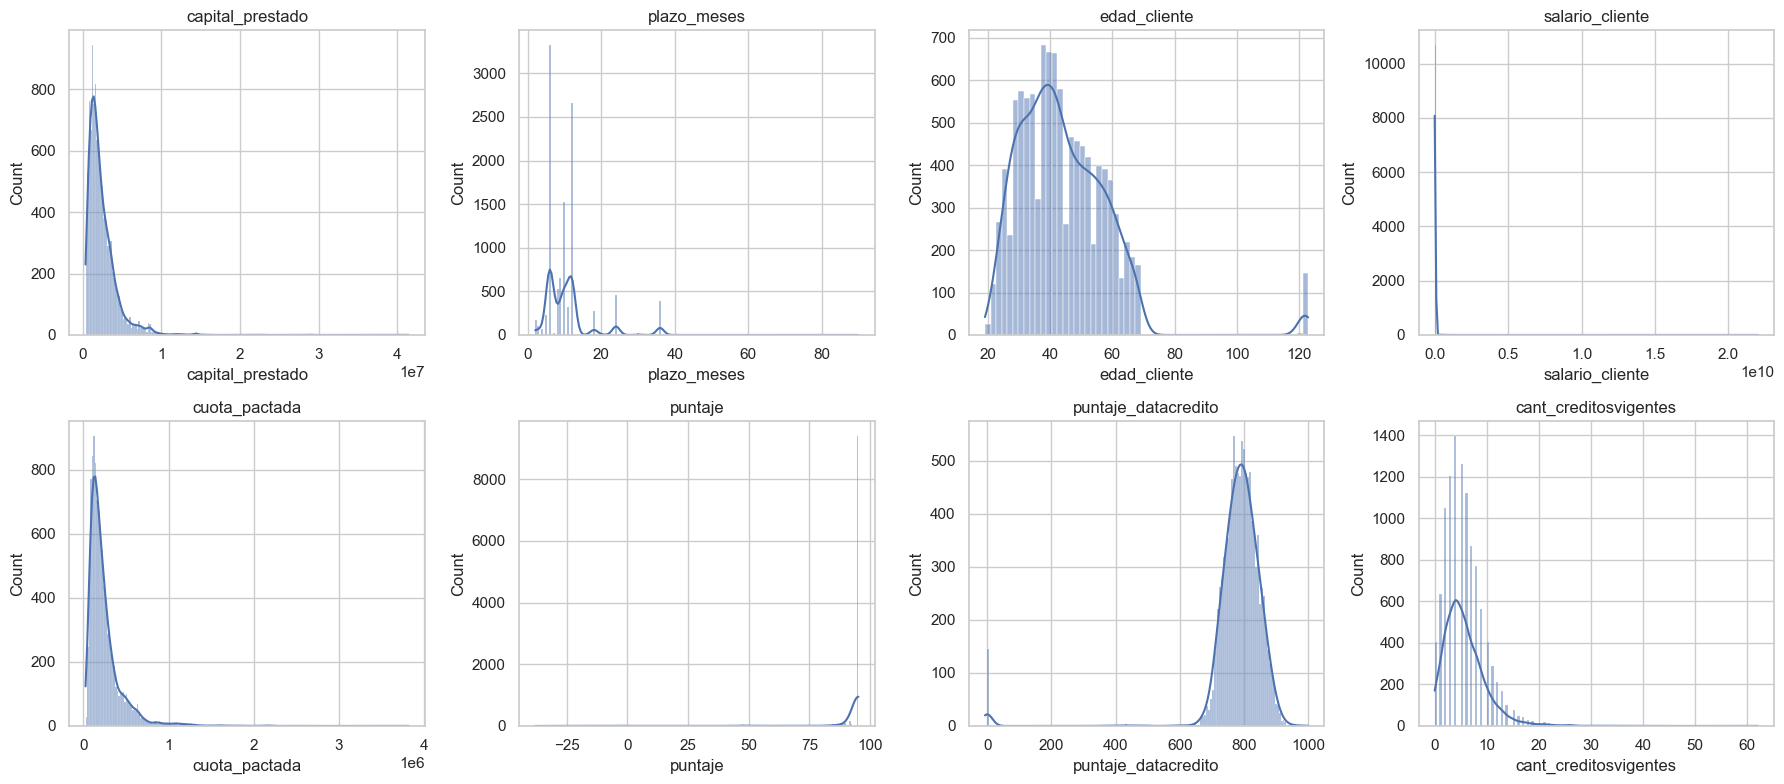

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretación:** `capital_prestado` y `cuota_pactada` muestran una distribución sesgada a la derecha (la mayoría de créditos son de montos bajos/medios, con pocos muy grandes) — típico de variables financieras, no requiere corrección, solo tenerlo en cuenta para elegir modelos robustos a esa asimetría. `salario_cliente` se ve como una sola barra pegada a 0 porque los outliers de miles de millones distorsionan la escala del gráfico — confirma visualmente el hallazgo de la sección 1.4. `puntaje` se concentra casi todo en un valor fijo (~95.2), con una cola de valores negativos imposibles. `edad_cliente` tiene una distribución razonable entre 20-70 con la cola de valores >100 ya identificada.

### 2.2.1 Hallazgo adicional: `puntaje` casi no varía entre clientes

In [11]:
top_valor = df['puntaje'].value_counts(normalize=True).iloc[0] * 100
valor_mas_comun = df['puntaje'].value_counts().index[0]
print(f'Valor más frecuente de puntaje: {valor_mas_comun:.6f}, presente en el {top_valor:.1f}% de los clientes')

Valor más frecuente de puntaje: 95.227787, presente en el 87.4% de los clientes


**Interpretación:** el 87.4% de los clientes comparte el mismo valor exacto de `puntaje` (95.227787). Esto no es un patrón de negocio real — es evidencia de que, para la gran mayoría de casos, el sistema de origen usó un **valor por defecto/placeholder** en vez de calcular un puntaje individual. Consecuencia práctica: con tan poca varianza, `puntaje` aporta muy poca información predictiva real al modelo (el 87.4% de las filas tienen el mismo valor, así que no ayuda a distinguir entre clientes). **Regla propuesta:** documentar esto como hallazgo de calidad de datos para el equipo de origen, y en el Avance #2 evaluar el desempeño del modelo con y sin esta variable para confirmar si de verdad aporta o si conviene excluirla.

### 2.2.2 Hallazgo adicional: outliers en `cant_creditosvigentes`

In [12]:
q1, q3 = df['cant_creditosvigentes'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
outliers = (df['cant_creditosvigentes'] > lim_sup).sum()
print(f'Límite superior IQR: {lim_sup:.1f}')
print(f'Clientes por encima del límite: {outliers} ({outliers/len(df)*100:.2f}%)')
print('Top 10 valores más altos:', df["cant_creditosvigentes"].sort_values(ascending=False).head(10).tolist())

Límite superior IQR: 15.5
Clientes por encima del límite: 242 (2.25%)
Top 10 valores más altos: [62, 38, 36, 35, 35, 34, 33, 32, 32, 31]


**Interpretación:** 242 clientes (2.25%) superan el límite estadístico normal de créditos vigentes (15.5), con casos extremos de hasta 62 créditos simultáneos. A diferencia del salario, aquí **sí es plausible que existan casos reales** (clientes con múltiples microcréditos activos), por lo que no se recomienda eliminarlos. **Regla propuesta:** igual que con salario y otros préstamos, aplicar winsorización (cap al percentil 99) en `ft_engineering.py`, en vez de un rango fijo o eliminación, preservando el caso real pero evitando que valores extremos distorsionen el entrenamiento.

### 2.3 Análisis univariable — variables categóricas

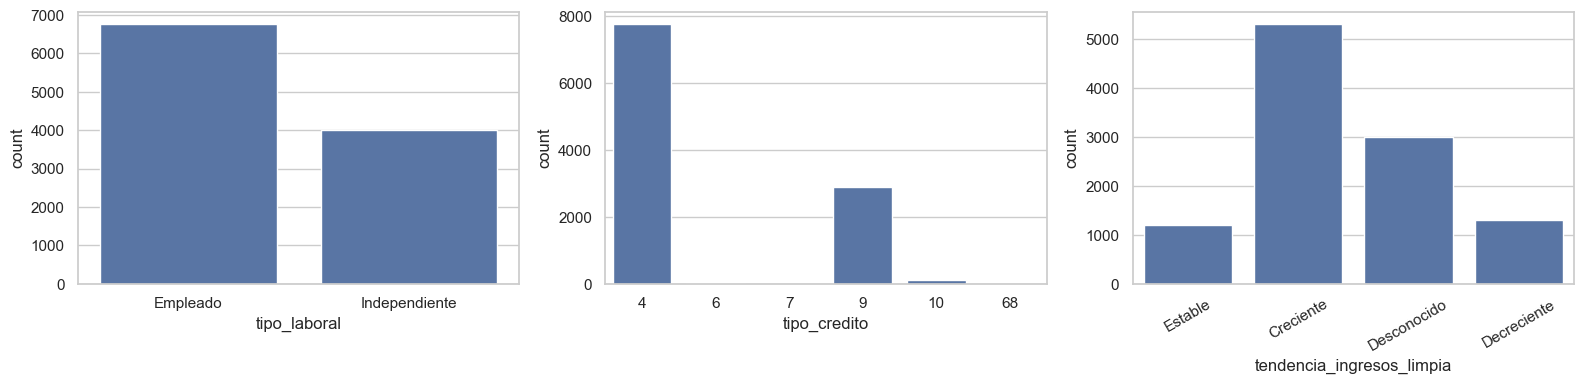

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='tipo_laboral', ax=axes[0])
sns.countplot(data=df, x='tipo_credito', ax=axes[1])
sns.countplot(data=df, x='tendencia_ingresos_limpia', ax=axes[2])
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Interpretación:** la mayoría de clientes son `Empleado` (~63%) frente a `Independiente` (~37%). En `tipo_credito` predominan los códigos 4 y 9, con 6, 7 y 10 mucho menos frecuentes y el valor 68 prácticamente inexistente (candidato a ser un código erróneo, a validar con el área de negocio antes de asumirlo como categoría real). En `tendencia_ingresos_limpia`, 'Creciente' es la más común entre las categorías válidas, y 'Desconocido' (nuestros datos corruptos recodificados) es comparable en tamaño a 'Estable' — confirma que no es un grupo despreciable.

### 2.4 Análisis bivariable — variables vs. Pago_atiempo

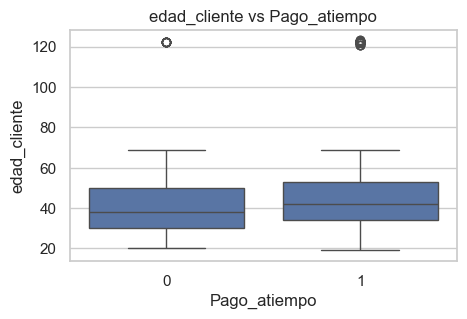

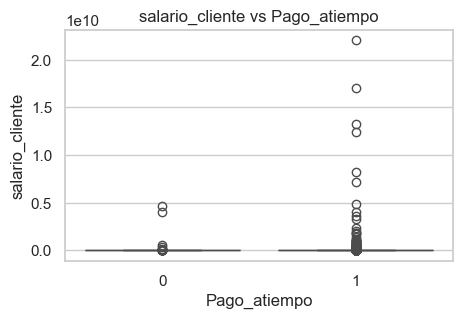

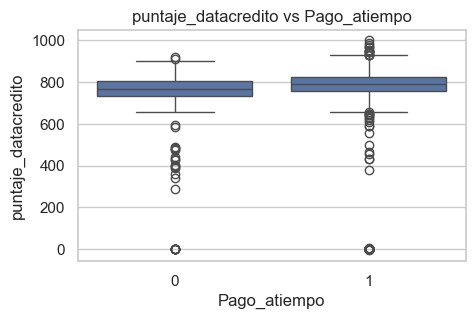

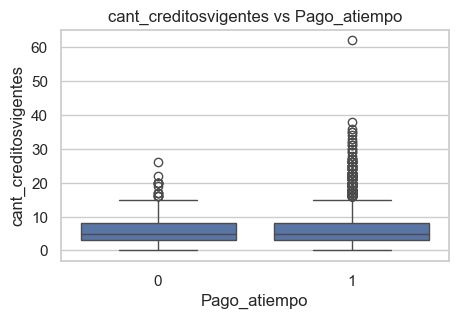

In [14]:
for col in ['edad_cliente', 'salario_cliente', 'puntaje_datacredito', 'cant_creditosvigentes']:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=df, x='Pago_atiempo', y=col)
    plt.title(f'{col} vs Pago_atiempo')
    plt.show()

In [15]:
df.groupby('Pago_atiempo')[num_cols].median().T

Pago_atiempo,0,1
capital_prestado,2.268000e+06,1.908446e+06
plazo_meses,1.000000e+01,1.000000e+01
edad_cliente,3.800000e+01,4.200000e+01
salario_cliente,3.000000e+06,3.000000e+06
cuota_pactada,1.990020e+05,1.825760e+05
puntaje,2.541945e+01,9.522779e+01
puntaje_datacredito,7.680000e+02,7.920000e+02
cant_creditosvigentes,5.000000e+00,5.000000e+00


**Interpretación:** comparando medianas por grupo, los clientes que **no** pagan a tiempo (0) piden un `capital_prestado` mediano más alto (2.27M vs 1.91M) y son en mediana **más jóvenes** (38 vs 42 años) que quienes sí pagan. En `puntaje_datacredito` el boxplot muestra que el grupo que no paga tiene mediana algo más baja y más dispersión hacia valores bajos — coherente con la intuición de negocio (menor score de central de riesgo → mayor probabilidad de incumplimiento). Esto convierte a `puntaje_datacredito`, `capital_prestado` y `edad_cliente` en candidatos fuertes de variables predictivas para el Avance #2.

In [16]:
pd.crosstab(df['tipo_laboral'], df['Pago_atiempo'], normalize='index').round(3) * 100

Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.3,95.7
Independiente,5.5,94.5


In [17]:
pd.crosstab(df['tendencia_ingresos_limpia'], df['Pago_atiempo'], normalize='index').round(3) * 100

Pago_atiempo,0,1
tendencia_ingresos_limpia,,
Creciente,3.9,96.1
Decreciente,6.3,93.7
Desconocido,5.6,94.4
Estable,4.6,95.4


**Interpretación:** revisar si `tipo_laboral` y `tendencia_ingresos_limpia` muestran tasas de no-pago distintas entre categorías. Si alguna categoría concentra una tasa de no-pago notablemente más alta que el 4.75% general, es una señal de riesgo a documentar como regla de negocio y a resaltar en el README del Avance #3.

### 2.5 Análisis multivariable

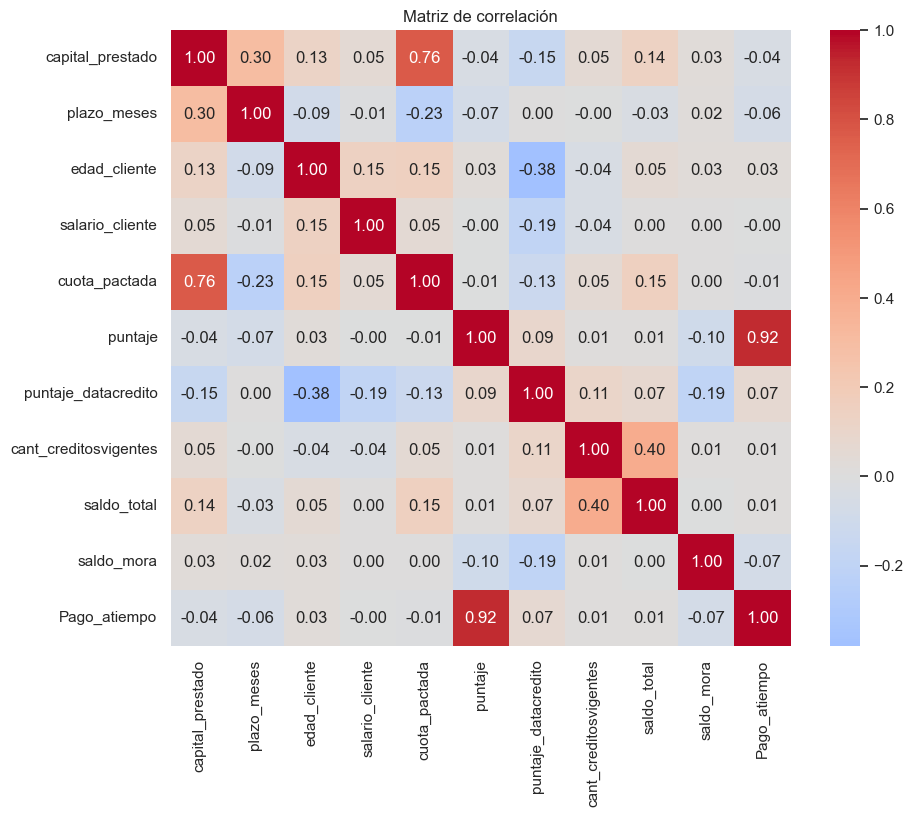

In [18]:
corr_cols = num_cols + ['saldo_total', 'saldo_mora', 'Pago_atiempo']
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

**Interpretación:** se revisa la fila/columna `Pago_atiempo` de la matriz para identificar qué variables numéricas están más (o menos) correlacionadas linealmente con el incumplimiento. Correlaciones cercanas a 0 no significan 'sin relación' — pueden existir relaciones no lineales que un modelo de árboles (Random Forest, XGBoost) sí capturaría, aunque la correlación de Pearson no lo muestre.

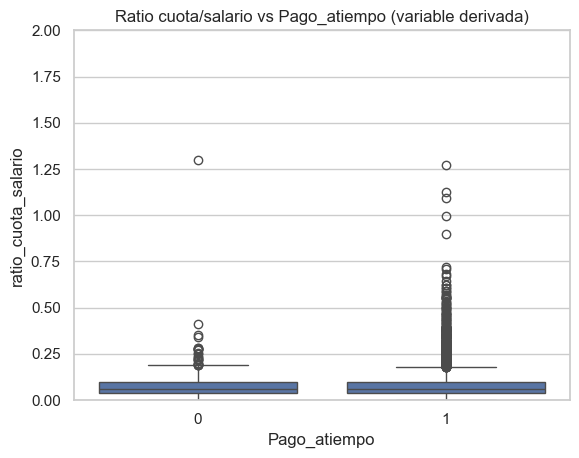

In [19]:
df['ratio_cuota_salario'] = df['cuota_pactada'] / df['salario_cliente'].replace(0, np.nan)
sns.boxplot(data=df, x='Pago_atiempo', y='ratio_cuota_salario')
plt.ylim(0, 2)
plt.title('Ratio cuota/salario vs Pago_atiempo (variable derivada)')
plt.show()

**Interpretación:** esta variable derivada mide qué proporción del ingreso del cliente se destina a la cuota del crédito — un indicador clásico de capacidad de pago. Un ratio alto (cuota que consume gran parte del salario) debería asociarse a mayor riesgo de no pago; se debe validar visualmente en el boxplot antes de usarla como feature.

## 3. Conclusiones del EDA y reglas de validación de datos
1. **Desbalance de clases (95.25% / 4.75%)** → usar ROC-AUC/PR-AUC/recall/F1, no accuracy; considerar `class_weight='balanced'` o SMOTE en el Avance #2.
2. **`tendencia_ingresos` corrupta (~27% de filas)** → recodificada a `tendencia_ingresos_limpia` con categoría `Desconocido`. Regla de validación futura: cualquier valor fuera de {Estable, Creciente, Decreciente} se marca como sospechoso en el pipeline de ingesta.
3. **Outliers imposibles por rango físico:** `edad_cliente` (>100 años), `puntaje` (fuera de 0-100), `puntaje_datacredito` (fuera de 150-999) → deben filtrarse o marcarse como inválidos antes de entrenar, no imputarse.
4. **Outliers extremos por IQR:** `salario_cliente` y `total_otros_prestamos` tienen colas de valores absurdamente altos (miles de millones) → aplicar winsorización (cap al percentil 99) en `ft_engineering.py`.
5. **Nulos en columnas de saldo** (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`) → imputados con 0 (ausencia de deuda registrada), no con la media.
6. **`fecha_prestamo`** cubre nov-2024 a abr-2026; usar para detectar drift temporal en el Avance #3, NO como feature de entrada directa (evitaría leakage temporal).
7. **Variable derivada útil:** `ratio_cuota_salario` — candidata fuerte para el Avance #2.
8. **`tipo_credito` = 68** aparece con frecuencia casi nula frente a {4,6,7,9,10} → validar con negocio si es un código real antes de incluirlo tal cual en el encoding.
9. **`puntaje` casi no varía** — 87.4% de los clientes comparte el mismo valor exacto (95.227787), indicio de un valor por defecto del sistema de origen en vez de un cálculo real → evaluar en el Avance #2 si aporta valor predictivo o conviene excluirla del modelo.
10. **Outliers en `cant_creditosvigentes`** (2.25%, hasta 62 créditos vigentes) → a diferencia del salario, aquí sí son plausibles casos reales, por lo que se aplica winsorización (cap al percentil 99) en vez de eliminación.

In [20]:
df.to_csv('../Base_de_datos_eda.csv', index=False)
print('Guardado: Base_de_datos_eda.csv (listo para ft_engineering.py)')

Guardado: Base_de_datos_eda.csv (listo para ft_engineering.py)
